In [1]:
import jax, optax, sys, os, json, pickle, time, glob
from datetime import datetime
import orbax.checkpoint
import pyscripts.jax_amber3 as jaa
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import mdtraj as md
import netCDF4 as nc
import jax.numpy as jnp
from flax import linen as nn 
from flax.training import train_state, orbax_utils
jax.config.update("jax_enable_x64", True)

jax.print_environment_info(), jax.default_backend()

jax:    0.4.28
jaxlib: 0.4.28
numpy:  1.26.4
python: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
jax.devices (1 total, 1 local): [cuda(id=0)]
process_count: 1
platform: uname_result(system='Linux', node='genuinelyjollyjackalope', release='6.5.0-35-generic', version='#35~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Tue May  7 09:00:52 UTC 2', machine='x86_64')


$ nvidia-smi
Tue May 14 01:13:49 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.129.03             Driver Version: 535.129.03   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|==========================

(None, 'gpu')

In [2]:
from contextlib import contextmanager,redirect_stderr,redirect_stdout
from os import devnull

@contextmanager
def suppress_stdout_stderr():
    """A context manager that redirects stdout and stderr to devnull"""
    with open(devnull, 'w') as fnull:
        with redirect_stderr(fnull) as err, redirect_stdout(fnull) as out:
            yield (err, out)

#Batching data (class usage and slight alterations of code will allow me to store information about the data stream as atrributes)
class Data_stream():
    def __init__(self, rng_seed, num_total, num_batches, batch_size, data):
        self.rng_seed = rng_seed
        self.num_total = num_total
        self.num_batches = num_batches
        self.batch_size = batch_size
        self.data = data
        
    def __iter__(self):
        rng = npr.RandomState(self.rng_seed)
        while True:
            perm = rng.permutation(self.num_total)
            for i in range(self.num_batches):
                batch_idx = perm[i * self.batch_size:(i + 1) * self.batch_size]
                yield self.data[batch_idx]

def reparameterize(z_rng, z_mean, z_logvar):
    z_std = jnp.exp(0.5*z_logvar)
    z_eps = jax.random.normal(z_rng, z_logvar.shape)
    return z_mean + z_eps*z_std 


#VAE Classes
class V_Encoder(nn.Module):
    d_hidden: list
    latents: int
    dropout_rates: list
    
    @nn.compact
    def __call__(self, x):
        for i in range(len(self.d_hidden)):
            x = nn.relu(nn.Dense(self.d_hidden[i])(x))
            x = nn.Dropout(rate=self.dropout_rates[i])(x, deterministic=True)
        mean_x = nn.Dense(self.latents, name='fc5_mean')(x)
        logvar_x = nn.Dense(self.latents, name='fc5_logvar')(x)
        return mean_x, logvar_x 

class Encoder(nn.Module):
    d_hidden: list
    latents: int
    dropout_rates: list

    @nn.compact
    def __call__(self, x):
        for i in range(len(self.d_hidden)):
            x = nn.relu(nn.Dense(self.d_hidden[i])(x))
            x = nn.Dropout(rate=self.dropout_rates[i])(x, deterministic=True)
        x = nn.Dense(self.latents, name='f5')(x)
        return x
    
class Decoder(nn.Module):
    d_hidden: list
    out_dim: int
    dropout_rates: list

    @nn.compact
    def __call__(self, z):
        for i in range(len(self.d_hidden))[::-1]:
            z = nn.relu(nn.Dense(self.d_hidden[i])(z))
            z = nn.Dropout(rate=self.dropout_rates[i])(z, deterministic=True)
        z = nn.Dense(self.out_dim, name='f5')(z)
        return z
        
class AE(nn.Module):
    input_size: int
    hidden_layers: tuple
    dropout_rates: list
    latents: int

    def setup(self):
        self.encoder = Encoder(list(self.hidden_layers), self.latents, self.dropout_rates)
        self.decoder = Decoder(list(self.hidden_layers), self.input_size, self.dropout_rates)
    
    def __call__(self, x, z_rng):
        z_latent = self.encoder(x)
        return self.decoder(z_latent), z_latent
    
    def encode(self, x, z_rng):
        return self.encoder(x)
    
    def decode(self, z, z_rng):
        return self.decoder(z)
        
class VAE(nn.Module):
    input_size: int
    hidden_layers: tuple
    dropout_rates: list
    latents: int
        
    def setup(self):
        self.encoder = V_Encoder(list(self.hidden_layers), self.latents, self.dropout_rates)
        self.decoder = Decoder(list(self.hidden_layers), self.input_size, self.dropout_rates)

    def __call__(self, x, z_rng):
        z_mean, z_logvar = self.encoder(x)
        z = reparameterize(z_rng, z_mean, z_logvar)
        return self.decoder(z), z_mean, z_logvar
    
    def construct(self, z_mean, z_logvar, z_rng):
        z = reparameterize(z_rng, z_mean, z_logvar)
        return self.decoder(z)
    
    def encode(self, x, z_rng):
        return self.encoder(x)
    
    def decode(self, z, z_rng):
        return self.decoder(z)
    
    def mvn_latent_model(self, x, z_rng):
        return NotImplemented()

In [3]:
@jax.vmap
def atom_rmsd(a, b, potential_coefficient=None): # for arrays of (n_conf, n_atom*3)
    mn = a.shape[-1]//3
    x_inds, y_inds, z_inds = jnp.arange(0,mn), jnp.arange(mn, 2*mn), jnp.arange(2*mn, 3*mn)
    return jnp.sqrt(jnp.mean((b[x_inds] - a[x_inds])**2 + (b[y_inds] - a[y_inds])**2 + (b[z_inds] - a[z_inds])**2))

@jax.jit
def scaled_pot_enr_diff(a, b, potential_coefficient=None): # WITH A AS BATCH AND B AS RECON
    return ((gas_fun(a) - gas_fun(b))/gas_fun(a))**2 #Unitless quantity

@jax.jit
def summation_loss(a, b, potential_coefficient): # LET A BE BATCH AND B BE RECON
    # Make this the square root of the mean of the sum of squares of elements
    return atom_rmsd(a,b) + potential_coefficient * scaled_pot_enr_diff(a, b)

@jax.jit
def rmsd_step(state, batch_x, z_rng, potential_coefficient):
    def loss_fn(params, apply_fn):
        recon_x = apply_fn({'params':params}, batch_x, z_rng)[0]
        return jnp.sqrt(jnp.sum(atom_rmsd(batch_x, recon_x)**2))
    grads = jax.grad(loss_fn)(state.params, state.apply_fn)
    return state.apply_gradients(grads=grads)

@jax.jit
def rmsd_log_step(state, batch_x, z_rng, potential_coefficient):
    def loss_fn(params, apply_fn):
        recon_x = apply_fn({'params':params}, batch_x, z_rng)[0]
        return jnp.log(jnp.sqrt(jnp.sum(atom_rmsd(batch_x, recon_x)**2)))
    grads = jax.grad(loss_fn)(state.params, state.apply_fn)
    return state.apply_gradients(grads=grads)

@jax.jit
def potential_step(state, batch_x, z_rng, potential_coefficient):
    def loss_fn(params, apply_fn):
        recon_x = apply_fn({'params':params}, batch_x, z_rng)[0]
        return scaled_pot_enr_diff(batch_x, recon_x).mean()
    grads = jax.grad(loss_fn)(state.params, state.apply_fn)
    return state.apply_gradients(grads=grads)    

@jax.jit
def summation_step(state, batch_x, z_rng, potential_coefficient, weights=(1,1)):
    def loss_fn(params, apply_fn):
        recon_x = apply_fn({'params':params}, batch_x, z_rng)[0]
        return summation_loss(batch_x, recon_x, potential_coefficient).mean()
    grads = jax.grad(loss_fn)(state.params, state.apply_fn)
    return state.apply_gradients(grads=grads)

In [4]:
class NN_Experiment():
    def __init__(self, json_fn, make_dirs=True, from_json_params=False):
        """

        INIT PARAMETERS:
            json_fn: string or dict: if string, set from_json_params to False, and provide the json file name as a string
                                     if dict, set from_json_params to True, and provide the parameters as json_fn
            make_dirs: bool: 
        
        JSON PARAMETERS:
            fname_dcd: string: DCD File to obtain coordinates from
            fname_prmtop: string: topology file for energy function (can be pdb file if "report_potential" is false)
            fname_pdb: string: PDB file to be used for BAT coordinate conversions
            save_dir: string: Directory to save the output (A series of directories are built in this)
            data_dir: string: Specific data directory to save output (bypasses save_dir option - default "None")
            max_epoch: int: Cutoff epoch (no step will run beyond this epoch)
            latent_dim: int: Number of latent dimensions for the model
            test_slice: int: Can be integer 0 to 4 inclusive, which slice of every five frames to make the test set
            data_slice_start: int: first (index) frame to build the testing/training data from
            data_slice_end: int or string="None": last (index) frame to build the testing/training data from
            model_name: string: Identifier for this model
            batch_size: int: size of individual batches, (best practice is test_set_size % batch_size == 0)
            learning_rate: float: learning rate for the optimizer
            dropout_rates: [float]: 3-list of floats for the dropout rate of dropout layers (Dropout rate = 1 - retention_rate) (use zero for no dropout)
            potential_threshold: float: Threshold of potential energy deviation to declare training complete
            model_type: string in ["VAE", "AE"]: Whether to use a Variational AutoEncoder or an AutoEncoder
                                                    Dropout rates not recommended for VAE
            coordinate_scheme: string in ["BAT", "Cartesian"]: Coordinate Scheme (fname_pdb must not be None for "BAT")
            resume_latest: bool: if True, will attempt to reload a previous model
            report_potential: bool: if True, potential energy deviation of batches will be evaluated and stored in the netcdf file
            checkpoint_interval: int: Number of epochs in between checkpoints (save the NN every checkpoint_interval epochs)
        """
        #Get the information from the json file
        if not from_json_params:
            with open(json_fn, 'r') as g:
                self.json_params = json.load(g)
        else:
            #To use json parameters that are already in memeory, not just the file name, make from_json_params True and pass the params instead of the json_fn
            self.json_params = json_fn
        
        #Files
        print('Load Files')
        fname_dcd = self.json_params["fname_dcd"]
        fname_prmtop = self.json_params["fname_prmtop"]
        fname_pdb = self.json_params["fname_pdb"]
        self.n_latents = self.json_params["latent_dim"] #number of latents
        test_slice = self.json_params["test_slice"] #int zero to four inclusive for 20/80 split of test and train
        model_name = self.json_params["model_name"] #string for the model name
        save_dir = self.json_params["save_dir"] #with trailing slash:
        data_start, data_end = self.json_params["data_slice_start"], self.json_params["data_slice_end"] #Slice of data
        self.batch_size = self.json_params["batch_size"]
        learning_rate = self.json_params["learning_rate"]
        dropout_rates = self.json_params["dropout_rates"]
        model_type = self.json_params["model_type"]
        coordinate_scheme = self.json_params["coordinate_scheme"]
        self.model_name = model_name
        resume = self.json_params["resume_latest"]
        self.report_potential = self.json_params["report_potential"]

        print('Establish Directories')
        #Establish Model Directory
        model_dir = os.path.join(save_dir, f'{self.model_name}/')
        if not os.path.isdir(model_dir) and make_dirs:
            os.mkdir(model_dir)
        
        #Establish Data Directory
        if self.json_params["data_dir"] == 'None':
            latent_dir = os.path.join(model_dir, f'{self.n_latents:04d}_latents/')
            self.data_dir = os.path.join(latent_dir, f'rpt_{test_slice}/')
            if not os.path.isdir(latent_dir) and make_dirs:
                os.mkdir(latent_dir)
        else:
            self.data_dir = self.json_params["data_dir"]
        
        if not os.path.isdir(self.data_dir) and make_dirs:
            os.mkdir(self.data_dir)
        
        if data_end == 'None':
            data_end = None
        
        #Load and Align
        print('Load Data with MDTraj')
        c = md.load(fname_dcd, top=fname_prmtop)
        c = c.superpose(c) # FEED IN ALIGNED DATA
        coord_set = jnp.array(c.xyz.reshape(c.xyz.shape[0], -1))[data_start:data_end]
        num_samples, input_size = coord_set.shape

        if self.report_potential:
            global gas_fun
            gas_fun, _ = jaa.get_amber_functions(fname_prmtop)
        
        #Change Coordinates to BAT if desired
        print('Coordinates')
        assert coordinate_scheme in ["Cartesian", "BAT"]
        self.coordinate_scheme = coordinate_scheme

        if coordinate_scheme == "BAT":
            print('Running BAT Conversion')
            import pyscripts.jax_BAT as jax_BAT
            import MDAnalysis as mda
            u = mda.Universe(fname_pdb, fname_dcd)
            ag = u.select_atoms("all")
            ag.guess_bonds()
            self.BAT = jax_BAT.BAT_jax(ag)
            self.BAT.run()
            coord_set = self.BAT.results.bat
            print('Done with BAT Conversion')
        else:
            pass
        
        #make test and train sets
        print('Batch data')
        test_indices = np.array(range(test_slice, num_samples, 5)) #every fifth frame
        train_indices = np.array([element for element in range(num_samples) if element not in test_indices])
        self.test_data = coord_set[test_indices]
        self.train_data = coord_set[train_indices]
        print(self.train_data.shape, self.test_data.shape)
        
        #Initialize Model
        print('Model Init')
        assert model_type in ['VAE', 'AE']
        self.model_type = model_type
        #make hidden layers
        hidden_layers = [input_size]*3
        if model_type == 'VAE':
            self.model = VAE(input_size=input_size, latents=self.n_latents,
                             hidden_layers=hidden_layers, dropout_rates=dropout_rates)
        elif model_type == 'AE':
            self.model = AE(input_size=input_size, latents=self.n_latents,
                            hidden_layers=hidden_layers, dropout_rates=dropout_rates)

        rng_init = jax.random.PRNGKey(self.n_latents)
        rng, key = jax.random.split(rng_init)
        self.state = train_state.TrainState.create(apply_fn=self.model.apply,
                                                   params=self.model.init(key, coord_set, rng_init)['params'],
                                                   tx=optax.adam(learning_rate=learning_rate))
        self.epoch = 0
        self.current_potential_coefficient = 0

        #Checkpointer
        print('Checkpointer')
        self.orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
        options = orbax.checkpoint.CheckpointManagerOptions(max_to_keep=2, save_interval_steps=json_params['checkpoint_interval'])
        manager_dir = os.path.join(self.data_dir, 'checkpoint_managed')
        self.checkpoint_manager = orbax.checkpoint.CheckpointManager(manager_dir, self.orbax_checkpointer, options)

        
        print('Batch Data')
        num_train = self.train_data.shape[0]
        num_complete_batches, leftover = divmod(num_train, self.batch_size)
        self.num_train_batches = num_complete_batches + bool(leftover)
        self.train_batches = Data_stream(self.n_latents, num_train, self.num_train_batches, self.batch_size, self.train_data)
        
        num_test = self.test_data.shape[0]
        num_complete_batches, leftover = divmod(num_test, self.batch_size)
        self.num_test_batches = num_complete_batches + bool(leftover)
        self.test_batches = Data_stream(self.n_latents, num_test, self.num_test_batches, self.batch_size, self.test_data)
        
        #Initialize data_storage
        print('Establish NCs')
        self.nc_data_file = os.path.join(self.data_dir, f'model_{self.model_name}_{self.n_latents:04d}.nc')
        self.nc_checkpoint_file = os.path.join(self.data_dir, f'model_{self.model_name}_{self.n_latents:04d}_checkpoint.nc')
        
        #Handle Resuming a Simulation or not
        if resume:
            self.rootgrp = self.establish_netcdf(self.nc_data_file, open_mode='a')
            ckpt_fn = sorted(glob.glob(manager_dir + "/*/default/"))[-1]
            self.epoch = int(ckpt_fn.split(os.sep)[-3]) + 1
            self.load_model_from_ckpt(ckpt_fn)
        else:
            self.rootgrp = self.establish_netcdf(self.nc_data_file)
        print('Epoch', self.epoch)
        print('NC', self.rootgrp)
        print('Model', self.model)
        print("INITIALIZATION COMPLETE")

    def establish_netcdf(self, nc_filename, open_mode='w'):
        rootgrp = nc.Dataset(nc_filename, open_mode, format='NETCDF4')
        
        if open_mode == 'w':
            traingrp = rootgrp.createGroup('Train')
            testgrp = rootgrp.createGroup('Test')
        
            traingrp.createDimension('epoch', None)
            traingrp.createDimension('batch', self.num_train_batches)
        
            testgrp.createDimension('epoch', None)
            testgrp.createDimension('batch', self.num_test_batches)
        
            for grp in [traingrp, testgrp]:
                rmsd = grp.createVariable('RMSD', 'f4', ('epoch', 'batch',))
                rmsd.units = "Nanometer"
                if self.report_potential:
                    pot = grp.createVariable('Potential', 'f8', ('epoch', 'batch',))
                    pot.units = "KJ/mol"
                    summ = grp.createVariable('Summation', 'f8', ('epoch', 'batch',))
                    summ.units = 'Unitless'
                grp.history = "Created" + time.ctime(time.time())
            
            if self.report_potential:
                coef = traingrp.createVariable('Potential Coefficient', 'f4', ('epoch',))
                coef.units = 'Unitless'
            
        return rootgrp

    def checkpoint_netcdf(self):
        with nc.Dataset(self.nc_checkpoint_file, "w") as dst:
            for grp_name, grp in self.rootgrp.groups.items():
                dst.createGroup(grp_name)
                # copy global attributes all at once via dictionary
                dst[grp_name].setncatts(grp.__dict__)
                # copy dimensions
                for name, dimension in grp.dimensions.items():
                    dst[grp_name].createDimension(name, (len(dimension) if not dimension.isunlimited() else None))
                # copy all file data
                for name, variable in grp.variables.items():
                    x = dst[grp_name].createVariable(name, variable.datatype, variable.dimensions)
                    dst[grp_name][name][:] = grp[name][:]
                    # copy variable attributes all at once via dictionary
                    dst[grp_name][name].setncatts(grp[name].__dict__)
    
    
    def load_model_from_ckpt(self, chkpt_fn):
        self.state = self.orbax_checkpointer.restore(chkpt_fn, item=self.state)
    
    def write_traj(self, identifier, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
        fname = self.data_dir + f'{identifier}_{self.model_name}{self.n_latents:04d}.dcd'
        
        if traj_xyz.shape[-1] != 3:
            traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
        
        with md.formats.DCDTrajectoryFile(fname, 'w') as f:
            f.write (traj_xyz*10) #*10 because mdtraj loads data in nm but saves it in angstrom
    
    def write_decoded_traj(self, idfn=None):
        rng = jax.random.PRNGKey(self.epoch)
        rng, key = jax.random.split(rng)
        recon_test = self.state.apply_fn({'params':self.state.params}, self.test_data, rng)
        if idfn != None:
            self.write_traj(idfn, recon_test[0])
        else:
            self.write_traj(f"recon_test", recon_test[0])
    
    def eval_batches(self, batch_set, eval_function, potential_coefficient):
        vals = jnp.empty((batch_set.num_batches, self.batch_size))
        f = iter(batch_set)
        
        for i in range(batch_set.num_batches):
            #Get Batch
            batch = next(f)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            recon = self.state.apply_fn({'params':self.state.params}, batch, rng)[0]
            #Eval Batch
            if self.coordinate_scheme == 'BAT':
                with suppress_stdout_stderr():
                    batch, recon = self.BAT.VCartesian(batch).reshape(batch.shape[0], -1), self.BAT.VCartesian(recon).reshape(recon.shape[0], -1)
            vals = vals.at[i, :].set(eval_function(batch, recon, potential_coefficient))
        
        return vals
        
    def eval_rmsd_only(self, rng):
        self.rootgrp['Train'].variables['RMSD'][self.epoch, :] = jnp.mean(self.eval_batches(self.train_batches, atom_rmsd, None), axis=1)
        self.rootgrp['Test'].variables['RMSD'][self.epoch, :] = jnp.mean(self.eval_batches(self.test_batches, atom_rmsd, None), axis=1)
        most_recent_results = []
        for grp in (self.rootgrp['Train'], self.rootgrp['Test']):
            most_recent_results.append(grp.variables['RMSD'][self.epoch, :].mean())
        return most_recent_results
        
    def eval_losses(self, rng, potential_coefficient):
        """
        Shape of return is train_rmsd, train_potential, train_summ, test_rmsd, test_potential, test_summ, lambda
        """
        #After all batches seen this epoch
        #recon_train = self.state.apply_fn({'params':self.state.params}, self.train_data, rng)
        #recon_test = self.state.apply_fn({'params':self.state.params}, self.test_data, rng)

        self.rootgrp['Train'].variables['RMSD'][self.epoch, :] = jnp.mean(self.eval_batches(self.train_batches, atom_rmsd, None), axis=1)
        self.rootgrp['Test'].variables['RMSD'][self.epoch, :] = jnp.mean(self.eval_batches(self.test_batches, atom_rmsd, None), axis=1)
        
        self.rootgrp['Train'].variables['Potential'][self.epoch, :] = jnp.mean(self.eval_batches(self.train_batches, scaled_pot_enr_diff, None), axis=1)
        self.rootgrp['Test'].variables['Potential'][self.epoch, :] = jnp.mean(self.eval_batches(self.test_batches, scaled_pot_enr_diff, None), axis=1)
        
        self.rootgrp['Train'].variables['Summation'][self.epoch, :] = jnp.mean(self.eval_batches(self.train_batches, summation_loss, potential_coefficient), axis=1)
        self.rootgrp['Test'].variables['Summation'][self.epoch, :] = jnp.mean(self.eval_batches(self.test_batches, summation_loss, potential_coefficient), axis=1)

        self.rootgrp['Train'].variables['Potential Coefficient'][self.epoch] = potential_coefficient
        
        most_recent_results = []
        for grp in (self.rootgrp['Train'], self.rootgrp['Test']):
            for variable in ['RMSD', 'Potential', 'Summation']:
                most_recent_results.append(grp.variables[variable][self.epoch, :].mean())
        most_recent_results.append(self.rootgrp['Train'].variables['Potential Coefficient'][self.epoch])
        
        return most_recent_results
    
    def train_batches_on_step(self, batch_set, step_function, potential_coefficient):
        f = iter(batch_set)
        for i in range(batch_set.num_batches):
            #Get Batch
            batch = next(f)
            #Train Batch
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            self.state = step_function(self.state, batch, rng, potential_coefficient)
        #After ANY EPOCH
        save_args = orbax_utils.save_args_from_target(self.state)
        self.checkpoint_manager.save(self.epoch, self.state, save_kwargs={'save_args': save_args})
        if self.epoch > 0 and self.epoch % 100 == 0:
            self.checkpoint_netcdf()
        
    def train_nepochs_on_rmsd_wo_reporting_potential(self, num_rmsd_epochs):
        while self.epoch < num_rmsd_epochs:
            epoch_start = datetime.now()
            #Training
            self.train_batches_on_step(self.train_batches, rmsd_step, self.current_potential_coefficient)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            #After all batches seen this epoch
            last_loss = self.eval_rmsd_only(rng)
            epoch_end = datetime.now() - epoch_start
            print('epoch', self.epoch,
                  'atom_rmsd_nm', '%.4E'%last_loss[0], '%.4E'%last_loss[1],
                  'Time:', epoch_end)
            self.epoch += 1
        return self.epoch
    
    def train_rmsd_to_lowest_wo_reporting_potential(self, num_move_ave=20, max_epoch=100000):
        """Train on the RMSD until overtraining is deteceted
            Stop training if the RMSD_loss of the test set is rising
        """
        test_rmsd_decreasing = True

        while test_rmsd_decreasing and self.epoch < max_epoch:
            epoch_start = datetime.now()
            #Training
            self.train_batches_on_step(self.train_batches, rmsd_step, self.current_potential_coefficient)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            #After all batches seen this epoch
            last_loss = self.eval_rmsd_only(rng)
            epoch_end = datetime.now() - epoch_start
            print('epoch', self.epoch,
                  'atom_rmsd_nm', '%.4E'%last_loss[0], '%.4E'%last_loss[1],
                  'Time:', epoch_end)
            self.epoch += 1
            
            test_rmsd_decreasing = self.rootgrp['Test']['RMSD'][-2*num_move_ave:-num_move_ave, :].mean() > self.rootgrp['Test']['RMSD'][-num_move_ave:, :].mean()

        if not test_rmsd_decreasing:
            print('RMSD Lowest Run - Break Reason - Test Set Loss Increasing')
        
        return self.epoch
    
    def train_nepochs_on_rmsd(self, num_rmsd_epochs):
        """
        Train on the RMSD function alone, potential coefficient is zero
        """
        
        while self.epoch < num_rmsd_epochs:
            epoch_start = datetime.now()
            #Training
            self.train_batches_on_step(self.train_batches, rmsd_step, self.current_potential_coefficient)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            #After all batches seen this epoch
            last_loss = self.eval_losses(rng, self.current_potential_coefficient)
            epoch_end = datetime.now() - epoch_start
            print('epoch', self.epoch,
                  'atom_rmsd_nm', '%.4E'%last_loss[0], '%.4E'%last_loss[3],
                  'dPotEnr', '%.4E'%last_loss[1], '%.4E'%last_loss[4],
                  'Summation', '%.4E'%last_loss[2], '%.4E'%last_loss[5],
                  'L=%.4E'%last_loss[6], 'Time:', epoch_end)
            self.epoch += 1
        return self.epoch

    def train_rmsd_threshold(self, nm_cutoff=0.1, num_move_ave=10):
        """Train on the RMSD until a nm_cutoff is reached of the last num_mov_ave epochs
            Stop training if the threshold is reached, or the RMSD_loss of the test set is rising
        """
        rmsd_above_threshold = True
        test_rmsd_decreasing = True

        while rmsd_above_threshold and test_rmsd_decreasing:
            #Training
            self.train_batches_on_step(self.train_batches, rmsd_step, self.current_potential_coefficient)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            #After all batches seen this epoch
            last_loss = self.eval_losses(rng, self.current_potential_coefficient)
            print('epoch', self.epoch,
                  'atom_rmsd_nm', '%.4E'%last_loss[0], '%.4E'%last_loss[3],
                  'dPotEnr', '%.4E'%last_loss[1], '%.4E'%last_loss[4],
                  'Summation', '%.4E'%last_loss[2], '%.4E'%last_loss[5],
                  'L=%.4E'%last_loss[6])
            self.epoch += 1
            rmsd_above_threshold = self.rootgrp['Train']['RMSD'][-num_move_ave:, :].mean() > nm_cutoff or self.rootgrp['Test']['RMSD'][-num_move_ave:, :].mean() > nm_cutoff
            test_rmsd_decreasing = self.rootgrp['Test']['RMSD'][-2*num_move_ave:-num_move_ave, :].mean() > self.rootgrp['Test']['RMSD'][-num_move_ave:, :].mean()

        if not rmsd_above_threshold:
            print('RMSD Threshold Run - Break Reason - Threshold Reached')
        if not test_rmsd_decreasing:
            print('RMSD Threshold Run - Break Reason - Test Set Loss Increasing')
        
        return self.epoch

    def train_rmsd_to_lowest(self, num_move_ave=20, max_epoch=100000):
        """Train on the RMSD until overtraining is deteceted
            Stop training if the RMSD_loss of the test set is rising
        """
        test_rmsd_decreasing = True

        while test_rmsd_decreasing and self.epoch < max_epoch:
            #Training
            self.train_batches_on_step(self.train_batches, rmsd_log_step, self.current_potential_coefficient)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            #After all batches seen this epoch
            last_loss = self.eval_losses(rng, self.current_potential_coefficient)
            print('epoch', self.epoch,
                  'atom_rmsd_nm', '%.4E'%last_loss[0], '%.4E'%last_loss[3],
                  'dPotEnr', '%.4E'%last_loss[1], '%.4E'%last_loss[4],
                  'Summation', '%.4E'%last_loss[2], '%.4E'%last_loss[5],
                  'L=%.4E'%last_loss[6])
            self.epoch += 1
            test_rmsd_decreasing = self.rootgrp['Test']['RMSD'][-2*num_move_ave:-num_move_ave, :].mean() > self.rootgrp['Test']['RMSD'][-num_move_ave:, :].mean()

        if not test_rmsd_decreasing:
            print('RMSD Lowest Run - Break Reason - Test Set Loss Increasing')
        
        return self.epoch
    
    def train_potential_threshold(self, potential_coefficient=1, potential_threshold=1e-3, num_mov_ave=10):
        self.current_potential_coefficient = potential_coefficient
        potential_above_threshold = True
        test_potential_decreasing = True

        while potential_above_threshold or test_potential_decreasing:
            # Training
            self.train_batches_on_step(self.train_batches, potential_step, self.current_potential_coefficient)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            #After all batches seen this epoch
            last_loss = self.eval_losses(rng, self.current_potential_coefficient)
            print('epoch', self.epoch,
                  'atom_rmsd_nm', '%.4E'%last_loss[0], '%.4E'%last_loss[3],
                  'dPotEnr', '%.4E'%last_loss[1], '%.4E'%last_loss[4],
                  'Summation', '%.4E'%last_loss[2], '%.4E'%last_loss[5],
                  'L=%.4E'%last_loss[6])
            self.epoch += 1
            potential_above_threshold = (self.rootgrp['Train']['Potential'][-num_move_ave:, :].mean() > potential_threshold or
                                         self.rootgrp['Test']['Potential'][-num_move_ave:, :].mean() > potential_threshold)
            test_potential_decreasing = self.rootgrp['Test']['Potential'][-2*num_move_ave:-num_move_ave, :].mean() > self.rootgrp['Test']['Potential'][-num_move_ave:, :].mean()

        if not potential_above_threshold:
            print('Potential Threshold Run - Break Reason - Threshold Reached')
        if not test_potential_decreasing:
            print('Potential Threshold Run - Break Reason - Test Set Loss Increasing')
        
        return self.epoch

    def train_scaling_potential(self):
        """Scale the potential in by frequently changing the coefficient to make potential equal to rmsd"""
        # Every five epochs choose lambda as min(1, max(1.01*lambda[-1], RMSD/NSD))
        while self.current_potential_coefficient < 1:
            # Training
            self.train_batches_on_step(self.train_batches, summation_step, self.current_potential_coefficient)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            #After all batches seen this epoch
            last_loss = self.eval_losses(rng, self.current_potential_coefficient)
            print('epoch', self.epoch,
                  'atom_rmsd_nm', '%.4E'%last_loss[0], '%.4E'%last_loss[3],
                  'dPotEnr', '%.4E'%last_loss[1], '%.4E'%last_loss[4],
                  'Summation', '%.4E'%last_loss[2], '%.4E'%last_loss[5],
                  'L=%.4E'%last_loss[6])
            self.epoch += 1
            #Get the next pot_coef every 5 epochs
            if self.epoch % 5 == 0:
                #Choose the smaller between 1 and x, where x is the larger of (RMSD/Potential, 1% increase in the current coefficient)
                self.current_potential_coefficient = np.min((1, np.max((1.01*self.current_potential_coefficient, (self.rootgrp['Train'].variables['RMSD'][-5:, :].mean() / self.rootgrp['Train'].variables['Potential'][-5:, :].mean())))))
        print('Scaling Complete')
        return self.epoch

    def train_summation_threshold(self, potential_coefficient=1, potential_threshold=1e-3, num_move_ave=10):
        """
        Exactly the same as potential threshold, except the summation step is used instead
        """
        self.current_potential_coefficient = potential_coefficient
        potential_above_threshold = True
        test_potential_decreasing = True

        while potential_above_threshold or test_potential_decreasing:
            # Training
            self.train_batches_on_step(self.train_batches, summation_step, self.current_potential_coefficient)
            rng = jax.random.PRNGKey(self.epoch)
            rng, key = jax.random.split(rng)
            #After all batches seen this epoch
            last_loss = self.eval_losses(rng, self.current_potential_coefficient)
            print('epoch', self.epoch,
                  'atom_rmsd_nm', '%.4E'%last_loss[0], '%.4E'%last_loss[3],
                  'dPotEnr', '%.4E'%last_loss[1], '%.4E'%last_loss[4],
                  'Summation', '%.4E'%last_loss[2], '%.4E'%last_loss[5],
                  'L=%.4E'%last_loss[6])
            self.epoch += 1
            potential_above_threshold = (self.rootgrp['Train']['Potential'][-num_move_ave:, :].mean() > potential_threshold or
                                         self.rootgrp['Test']['Potential'][-num_move_ave:, :].mean() > potential_threshold)
            test_potential_decreasing = self.rootgrp['Test']['Potential'][-2*num_move_ave:-num_move_ave, :].mean() > self.rootgrp['Test']['Potential'][-num_move_ave:, :].mean()
        
        if not potential_above_threshold:
            print('Potential Threshold Run - Break Reason - Threshold Reached')
        if not test_potential_decreasing:
            print('Potential Threshold Run - Break Reason - Test Set Loss Increasing')
        
        return self.epoch

    def MAIN_train_rmsd_only(self, n_rmsd=1000, cutoff_epoch=100000):
        self.train_nepochs_on_rmsd(n_rmsd)
        self.train_rmsd_to_lowest(max_epoch=cutoff_epoch)
        return self.epoch

    def MAIN_train_rmsd_only_wo_reporting_potential(self, n_rmsd=1000, cutoff_epoch=100000):
        self.train_nepochs_on_rmsd_wo_reporting_potential(n_rmsd)
        self.train_rmsd_to_lowest_wo_reporting_potential(max_epoch=cutoff_epoch)
        return self.epoch

    def MAIN_scale_and_train_potential(self, cutoff_epoch=200000):
        self.train_scaling_potential()
        self.train_summation_threshold()
        return self.epoch

In [5]:
# json_params = {"fname_dcd": "/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/Simulation/decaalanine_1us_split3.dcd",
#                "fname_prmtop": "/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/Simulation/ala_deca_peptide.prmtop",
#                "fname_pdb": "/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/Simulation/ala_deca_peptide.pdb",
#                "save_dir": "/media/volume/Boltzmann2Boltzmann/githubs/Deep-MMS/",
#                "data_dir": "None",
#                "max_epoch": 30000,
#                "latent_dim": 4,
#                "test_slice": 1,
#                "data_slice_start": 0,
#                "data_slice_end": "None",
#                "model_name": "Crambin_AE_Dropout_RMSD_only",
#                "batch_size": 2000,
#                "learning_rate": 1e-06,
#                "dropout_rates": [0.1, 0.1, 0.1],
#                "potential_threshold": 0.05,
#                "model_type": "AE",
#                "coordinate_scheme": "Cartesian",
#                "resume_latest": True}

json_params = {"fname_dcd": "/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/HIV1p_split2.dcd",
               "fname_prmtop": "/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/HIV1p_protein_only.pdb",
               "fname_pdb": "/media/volume/Joseph-Large/githubs/Deep-MMS/Simulation/HIV1p_protein_only.pdb",
               "save_dir": "/media/volume/Joseph-Large/githubs/Deep-MMS/",
               "data_dir": "None",
               "max_epoch": 100000,
               "latent_dim": 777,
               "test_slice": 1,
               "data_slice_start": 0,
               "data_slice_end": "None",
               "model_name": "HIV1p_AE_Dropout_RMSD_only",
               "batch_size": 2000,
               "learning_rate": 1e-06,
               "dropout_rates": [0.1, 0.1, 0.1],
               "potential_threshold": 0.05,
               "model_type": "AE",
               "coordinate_scheme": "Cartesian",
               "resume_latest": False,
               "report_potential": False,
               "checkpoint_interval": 200}

In [6]:
experiment = NN_Experiment(json_params, from_json_params=True)

Load Files
Establish Directories
Load Data with MDTraj


2024-05-14 01:13:59.253841: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Coordinates
Batch data
(8000, 9897) (2000, 9897)
Model Init


Checkpointer
Batch Data
Establish NCs
Epoch 0
NC <class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
Model AE(
    # attributes
    input_size = 9897
    hidden_layers = [9897, 9897, 9897]
    dropout_rates = [0.1, 0.1, 0.1]
    latents = 777
)
INITIALIZATION COMPLETE


In [7]:
experiment.MAIN_train_rmsd_only_wo_reporting_potential()

2024-05-14 01:14:25.954012: W external/xla/xla/service/hlo_rematerialization.cc:2948] Can't reduce memory use below 1.37GiB (1470618384 bytes) by rematerialization; only reduced to 8.14GiB (8738227228 bytes), down from 9.01GiB (9672029132 bytes) originally


epoch 0 atom_rmsd_nm 7.2273E+00 7.2273E+00 Time: 0:00:17.431252
epoch 1 atom_rmsd_nm 7.1656E+00 7.1657E+00 Time: 0:00:01.464375
epoch 2 atom_rmsd_nm 7.1091E+00 7.1091E+00 Time: 0:00:00.781015
epoch 3 atom_rmsd_nm 7.0475E+00 7.0475E+00 Time: 0:00:00.888113
epoch 4 atom_rmsd_nm 6.9763E+00 6.9763E+00 Time: 0:00:00.776988
epoch 5 atom_rmsd_nm 6.8920E+00 6.8920E+00 Time: 0:00:00.799755
epoch 6 atom_rmsd_nm 6.7924E+00 6.7924E+00 Time: 0:00:00.902164
epoch 7 atom_rmsd_nm 6.6764E+00 6.6765E+00 Time: 0:00:00.819546
epoch 8 atom_rmsd_nm 6.5434E+00 6.5435E+00 Time: 0:00:00.798421
epoch 9 atom_rmsd_nm 6.3945E+00 6.3946E+00 Time: 0:00:00.790998
epoch 10 atom_rmsd_nm 6.2317E+00 6.2318E+00 Time: 0:00:00.796383
epoch 11 atom_rmsd_nm 6.0585E+00 6.0585E+00 Time: 0:00:00.789800
epoch 12 atom_rmsd_nm 5.8783E+00 5.8783E+00 Time: 0:00:00.798698
epoch 13 atom_rmsd_nm 5.6949E+00 5.6949E+00 Time: 0:00:00.792739
epoch 14 atom_rmsd_nm 5.5095E+00 5.5095E+00 Time: 0:00:00.794607
epoch 15 atom_rmsd_nm 5.3213E+00 5.

KeyboardInterrupt: 

In [7]:
#Attempt to resume a Bridges2 run with potential scaling

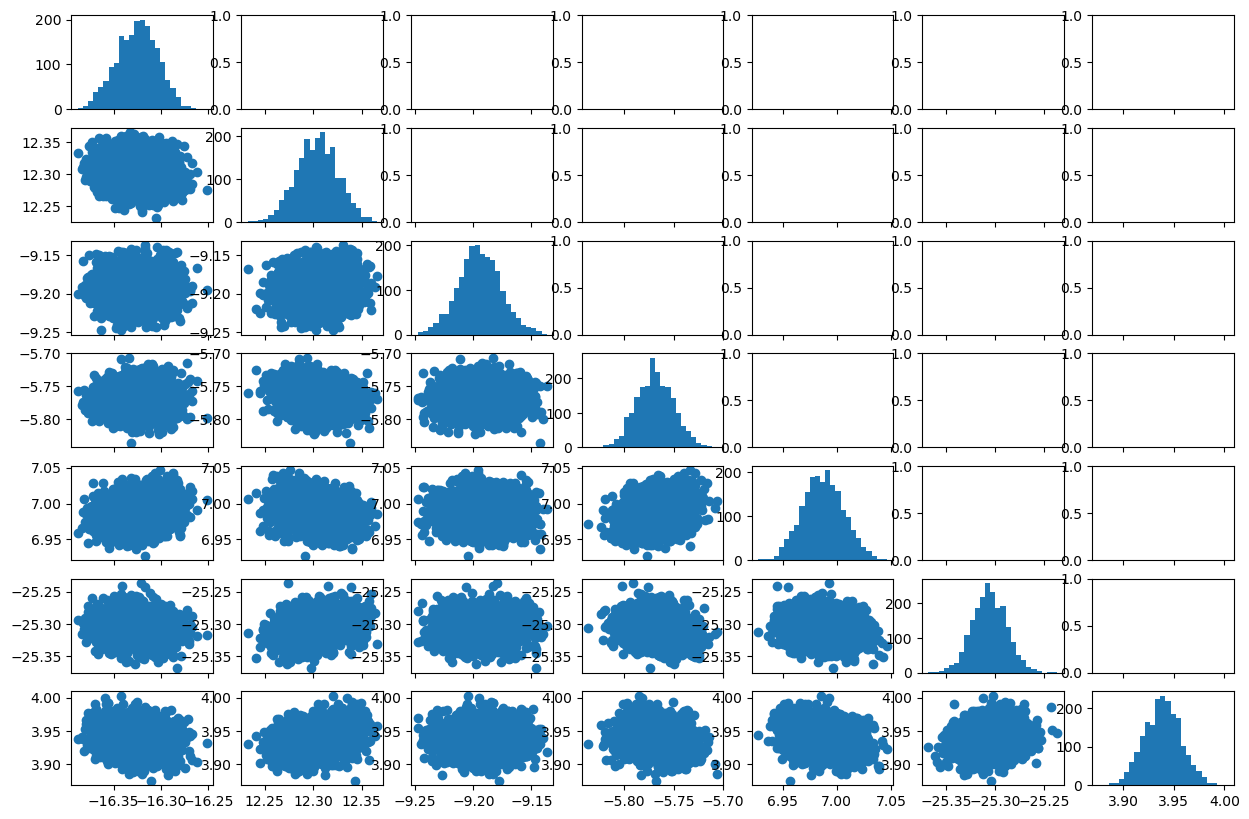

In [8]:
rng = jax.random.PRNGKey(experiment.epoch)
rng, key = jax.random.split(rng)
recon, latents = experiment.state.apply_fn({'params':experiment.state.params}, experiment.test_data, rng)

fig, axs = plt.subplots(experiment.n_latents, experiment.n_latents, figsize=(15,10), sharex='col')
for i in range(experiment.n_latents):
    for j in range(experiment.n_latents):
        #axs[i,j].scatter(latent[:,j], latent[:,i])
        if i > j:
            axs[i,j].scatter(latents[:,j], latents[:,i])
        elif i == j:
            axs[i,j].hist(latents[:, i], bins=25)

In [9]:
print(experiment.rootgrp)
print(experiment.rootgrp['Train'])
print(experiment.rootgrp['Test'])

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: Train, Test
<class 'netCDF4._netCDF4.Group'>
group /Train:
    history: CreatedMon May 13 23:55:51 2024
    dimensions(sizes): epoch(1017), batch(4)
    variables(dimensions): float32 RMSD(epoch, batch)
    groups: 
<class 'netCDF4._netCDF4.Group'>
group /Test:
    history: CreatedMon May 13 23:55:51 2024
    dimensions(sizes): epoch(1017), batch(1)
    variables(dimensions): float32 RMSD(epoch, batch)
    groups: 


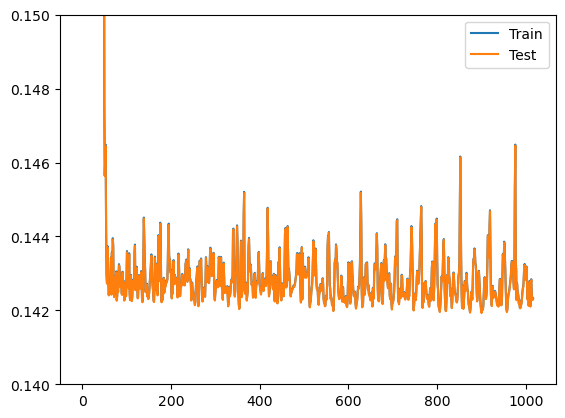

In [34]:
plt.clf()
_ = plt.plot(np.arange(rmsd_train.shape[0]), rmsd_train)
_ = plt.plot(np.arange(rmsd_test.shape[0]), rmsd_test)
plt.legend(['Train', 'Test'])
plt.ylim(0.14, .15)
plt.show()

In [8]:
rmsd_train = np.mean(experiment.rootgrp['Train'].variables['RMSD'], axis=1)
rmsd_test = np.mean(experiment.rootgrp['Test'].variables['RMSD'], axis=1)
d_tt = np.sqrt((rmsd_test - rmsd_train)**2)/rmsd_train * 100

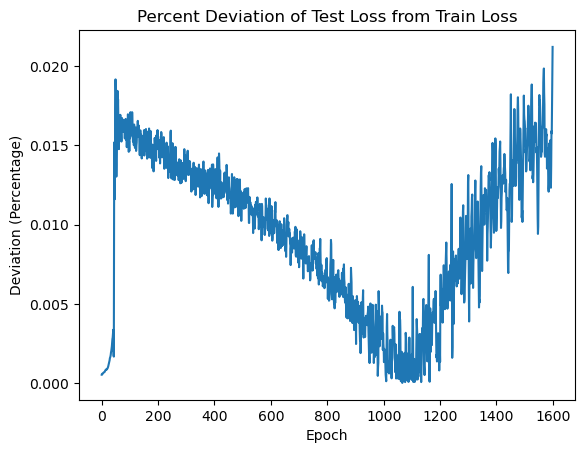

In [11]:
plt.clf()
_ = plt.plot(np.arange(d_tt.shape[0]), d_tt)
plt.xlabel('Epoch')
plt.ylabel('Deviation (Percentage)')
plt.title('Percent Deviation of Test Loss from Train Loss')
plt.show()

In [10]:
rng_init = jax.random.PRNGKey(54)
rng, key = jax.random.split(rng_init)
test_data = experiment.test_data
recon, latents = experiment.state.apply_fn({'params':experiment.state.params}, test_data, rng)

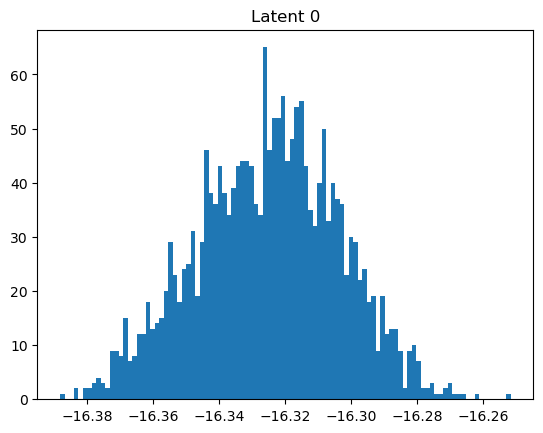

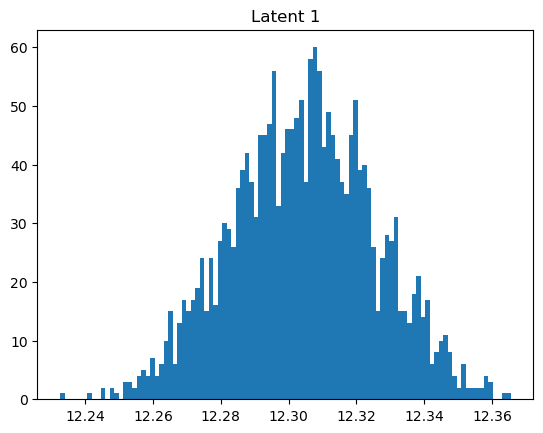

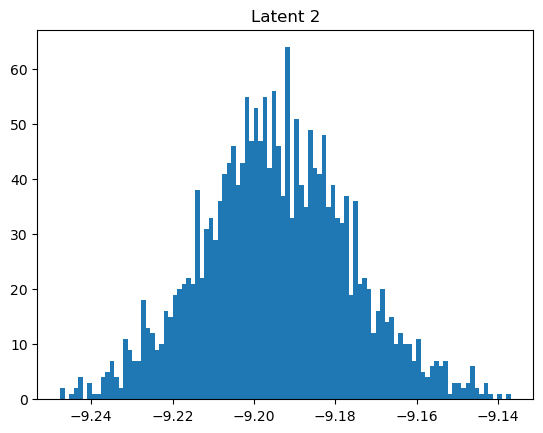

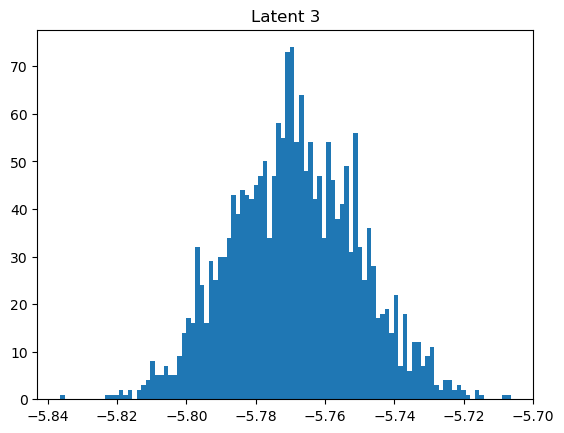

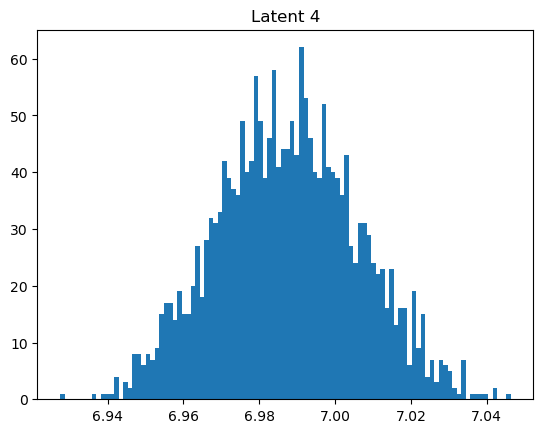

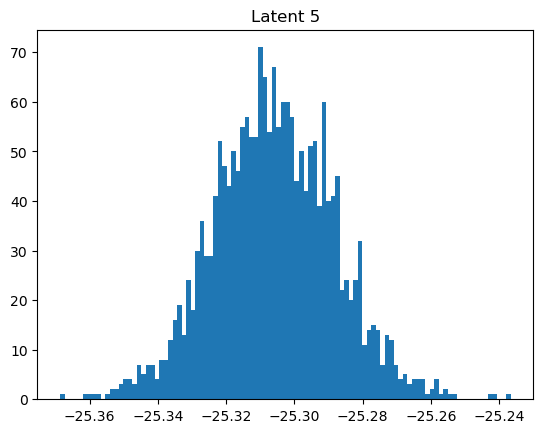

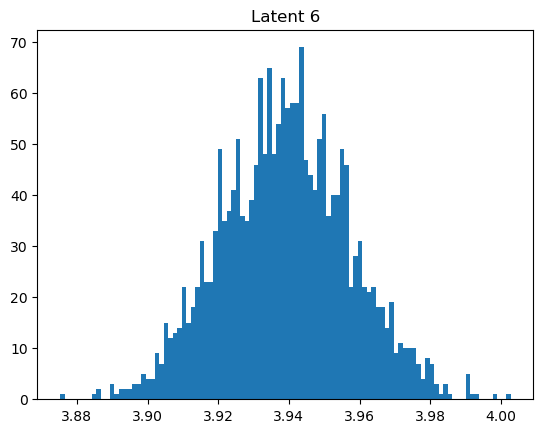

In [11]:
for i in range(latents.shape[-1]):
    plt.clf()
    plt.title(f'Latent {i}')
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

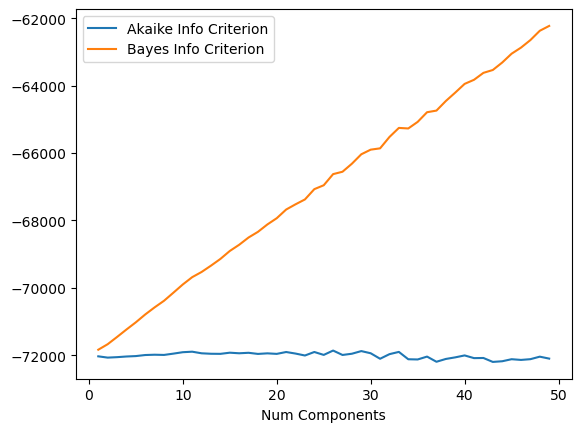

minimums: Akaike 43 Bayes 1


In [13]:
from sklearn.mixture import GaussianMixture
ics = []
for i in range(1, 50):
    X = np.array(latents)
    MM = GaussianMixture(n_components=i).fit(X)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()
print(f'minimums: Akaike {np.argmin(ics[:,1]) + 1} Bayes {np.argmin(ics[:,2]) + 1}')

In [14]:
X = np.array(latents)
MM = GaussianMixture(n_components=2).fit(X) #chosen based on above graph
samples = MM.sample(2000)[0]

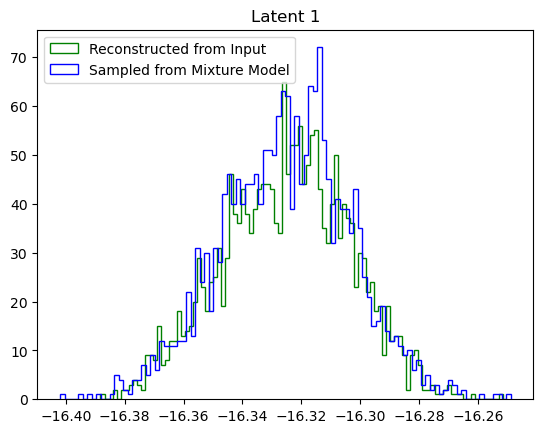

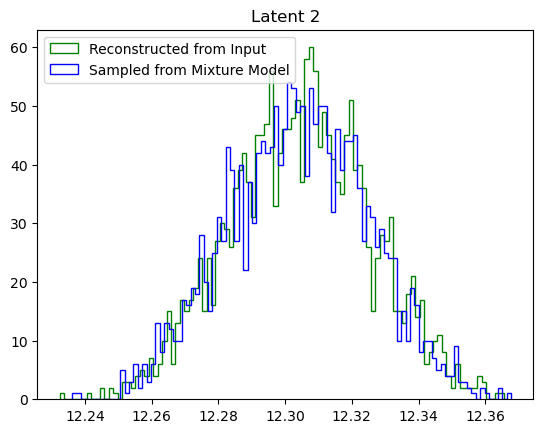

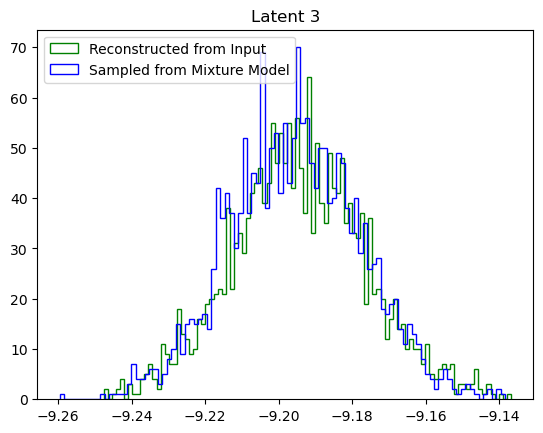

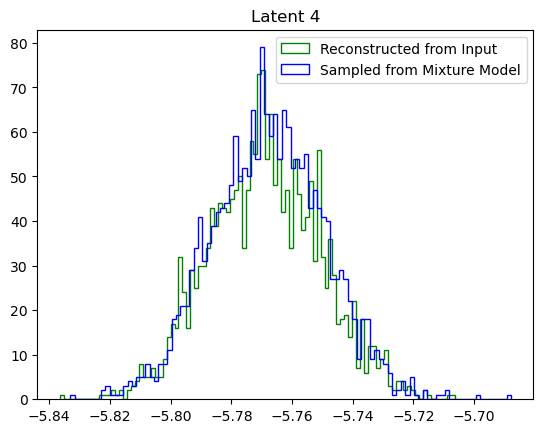

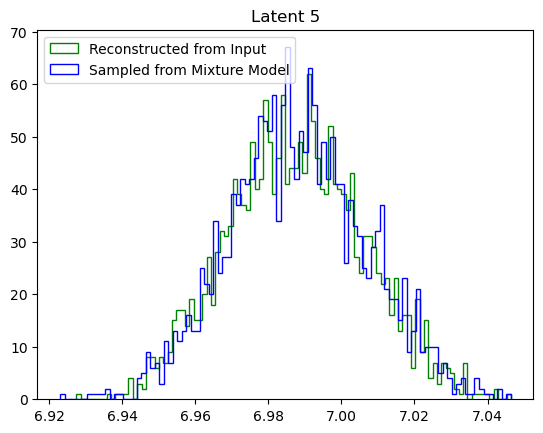

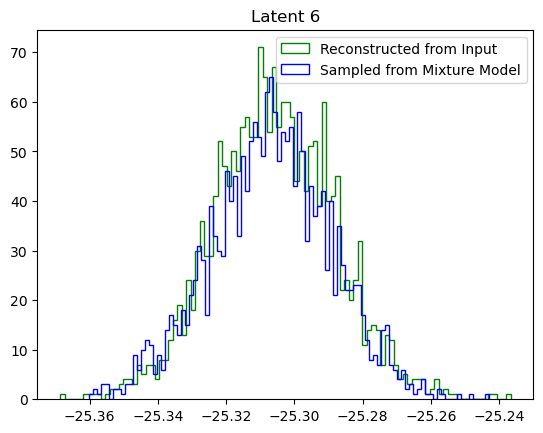

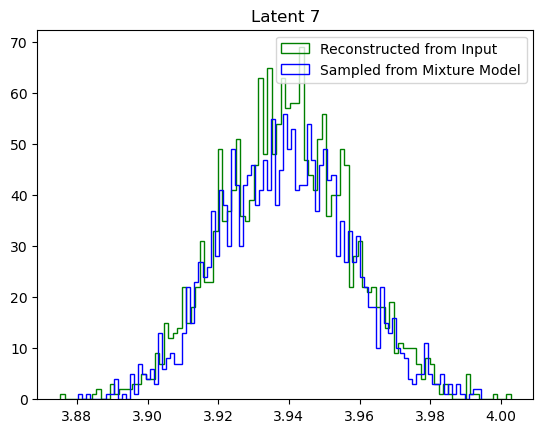

In [15]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:,i], bins=100, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=100, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

0 0 PearsonRResult(statistic=1.0, pvalue=0.0)
0 1 PearsonRResult(statistic=-0.12321738184475389, pvalue=3.237527096626268e-08)
0 2 PearsonRResult(statistic=-0.004002692882729473, pvalue=0.8580204054055519)
0 3 PearsonRResult(statistic=0.010831853702290952, pvalue=0.6282960393217772)
0 4 PearsonRResult(statistic=0.2239658731848885, pvalue=3.714207544871327e-24)
0 5 PearsonRResult(statistic=-0.11880925952147964, pvalue=9.882365678760708e-08)
0 6 PearsonRResult(statistic=-0.1762458895008549, pvalue=2.034036654941276e-15)
1 0 PearsonRResult(statistic=-0.12321738184475389, pvalue=3.237527096626268e-08)
1 1 PearsonRResult(statistic=1.0, pvalue=0.0)
1 2 PearsonRResult(statistic=0.12030728805046949, pvalue=6.793337352276709e-08)
1 3 PearsonRResult(statistic=-0.22545206321383054, pvalue=1.8274830959039655e-24)
1 4 PearsonRResult(statistic=-0.2766316757788114, pvalue=1.8483414971140974e-36)
1 5 PearsonRResult(statistic=0.2869601372255822, pvalue=3.218144000370696e-39)
1 6 PearsonRResult(statisti

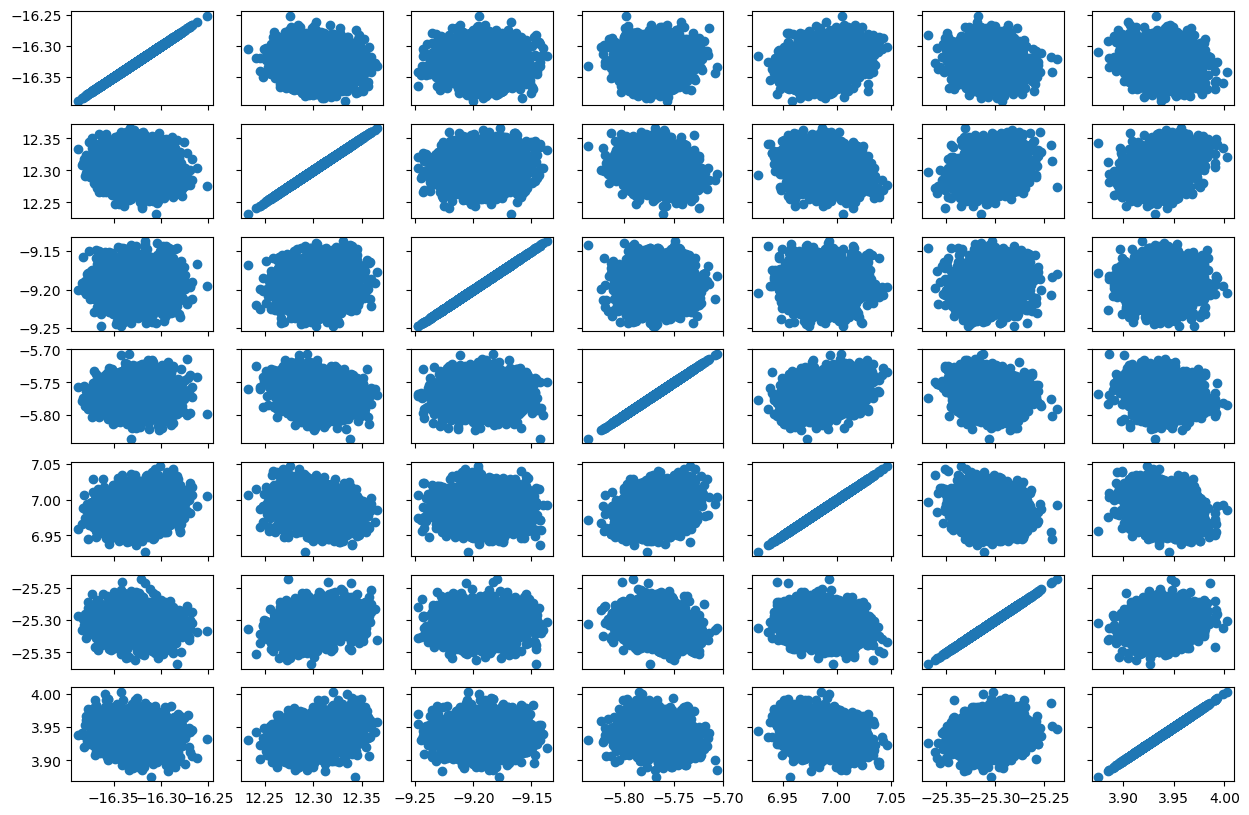

In [16]:
import scipy
n_L = latents.shape[-1]
fig, axs = plt.subplots(n_L, n_L, figsize=(15, 10), sharex='col', sharey='row')
for i in range(n_L):
    for j in range(n_L):
        axs[i,j].scatter(latents[:,j], latents[:,i])
        print(i, j, scipy.stats.pearsonr(latents[:,j], latents[:,i]))
fig.savefig('7L.png', dpi=600)

Excluding Outliers GMM - 880 RECON - 143


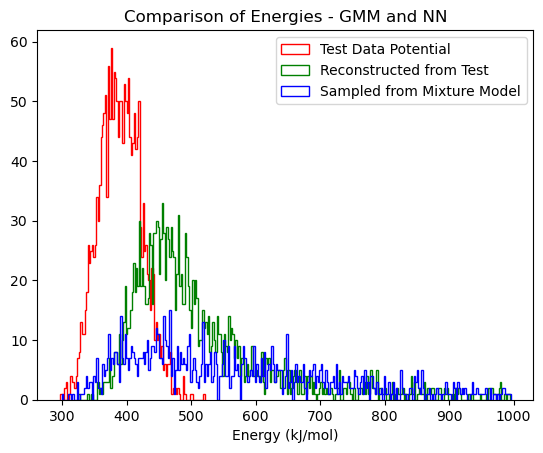

In [17]:
plt.clf()

recon_energies = gas_fun(recon)

decoded_samples = experiment.model.apply({'params': experiment.state.params}, samples, rng, method=experiment.model.decode)
sampled_energies = gas_fun(decoded_samples)

org_energies = gas_fun(experiment.test_data)

threshold = 1e3
num_excluded_gmm = len(sampled_energies) - len(sampled_energies[sampled_energies<threshold])
num_excluded_nn  = len(recon_energies) - len(recon_energies[recon_energies<threshold])
print(f'Excluding Outliers GMM - {num_excluded_gmm} RECON - {num_excluded_nn}')

_ = plt.hist(org_energies[org_energies < threshold], bins=100, histtype='step', color='r')
_ = plt.hist(recon_energies[recon_energies<threshold], bins=300, histtype='step', color='g')
_ = plt.hist(sampled_energies[sampled_energies<threshold], bins=300, histtype='step', color='b')

plt.legend(('Test Data Potential', 'Reconstructed from Test', 'Sampled from Mixture Model'))
plt.xlabel('Energy (kJ/mol)')
plt.title('Comparison of Energies - GMM and NN')
plt.show()

In [18]:
def write_traj(filename, traj_xyz): #(n conf, n_atoms*3) OR (n conf, n_atoms, 3)
    if traj_xyz.shape[-1] != 3:
        traj_xyz = traj_xyz.reshape(traj_xyz.shape[0], -1, 3)
    with md.formats.DCDTrajectoryFile(filename, 'w') as f:
        f.write(traj_xyz*10) #*10 because mdtraj loads data in nm but saves it in angstrom

my_dict = {'DA_TestData.dcd' : experiment.test_data, 'DA_ReconData.dcd' : recon, 'DA_GMM.dcd' : decoded_samples}
for key, value in zip(my_dict.keys(), my_dict.values()):
    write_traj(key, value)

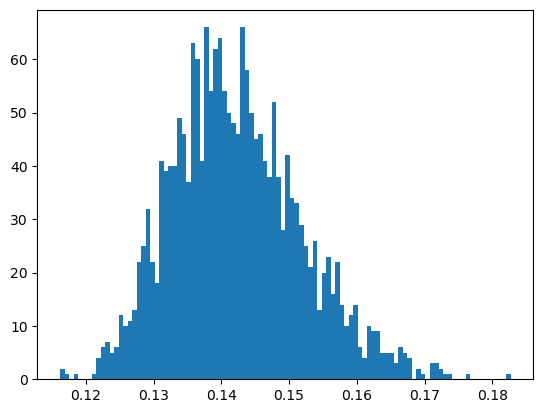

In [17]:
rmsds = atom_rmsd(experiment.test_data, recon)
plt.clf()
_ = plt.hist(rmsds, bins=100)
plt.show()
# ener_comp = scaled_pot_enr_diff(experiment.test_data, recon)
# plt.clf()
# _ = plt.hist(ener_comp[ener_comp < 5], bins=100)
# plt.show()

In [20]:
recon_train , _ = experiment.state.apply_fn({'params':experiment.state.params}, experiment.train_data, rng)
my_dict = {'DA_TrainData.dcd' : experiment.train_data, 'DA_ReconData_train.dcd' : recon_train}
for key, value in zip(my_dict.keys(), my_dict.values()):
    write_traj(key, value)